In [1]:
!pip install torch torchvision

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model import hierarchical_kmeans_resampling

# 1. Thiết lập thiết bị (Ưu tiên GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Tải model DINOv2 (Small version để chạy nhanh)
dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
dinov2_vits14.eval()

# 3. Chuẩn bị dữ liệu CIFAR-10
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

try:
    dataset = torchvision.datasets.CIFAR10(
        root='../data', 
        train=True, 
        download=False, 
        transform=transform
    )
    print("Thành công! Đã tìm thấy dữ liệu CIFAR-10 tại địa phương.")
except RuntimeError:
    print("Lỗi: Vẫn không tìm thấy. Hãy kiểm tra lại tên thư mục trong ../data/")

loader = DataLoader(dataset, batch_size=128, shuffle=False)

Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Thành công! Đã tìm thấy dữ liệu CIFAR-10 tại địa phương.


In [ ]:
# 4. Trích xuất Features (Lấy khoảng 2000-5000 ảnh để chạy cho nhanh)
features = []
labels_true = []
max_samples = None

print("Đang trích xuất features bằng DINOv2...")
with torch.no_grad():
    for i, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        # Trích xuất đặc trưng
        feat = dinov2_vits14(imgs)
        features.append(feat.cpu().numpy())
        labels_true.append(labels.numpy())
        
        # if (i + 1) * 64 >= max_samples:
        #     break

        count += imgs.size(0)
        if max_samples and count >= max_samples:
            break

X_features = np.vstack(features)
labels_true = np.concatenate(labels_true)
print(f"Hoàn thành! Kích thước tập đặc trưng: {X_features.shape}")

Đang trích xuất features bằng DINOv2...
Hoàn thành! Kích thước tập đặc trưng: (2048, 384)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)
X_features = pca.fit_transform(X_features)

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.metrics import calculate_acc, calculate_nmi
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans

# --- 1. Chạy Standard K-means (Baseline) ---
k_final = 10 # CIFAR-10 có 10 lớp
kmeans_std = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
std_labels = kmeans_std.fit_predict(X_features)

# --- 2. Chạy Hierarchical K-means (Ours) ---
# Chúng ta dùng cấu trúc k giảm dần: [40, 20, 10]
#ks_list = [40, 20, 10]
ks_list = [100, 50, 20]
results_hkm = hierarchical_kmeans_resampling(X_features, k_list=ks_list, T=3, m=20, r_t=30)
hkm_labels = results_hkm["final_labels"]

# --- 3. Tính toán và So sánh ---
acc_std = calculate_acc(labels_true, std_labels)
nmi_std = calculate_nmi(labels_true, std_labels)

acc_hkm = calculate_acc(labels_true, hkm_labels)
nmi_hkm = calculate_nmi(labels_true, hkm_labels)

print(f"{'Chỉ số':<15} | {'Standard K-means':<20} | {'Hierarchical K-means':<20}")
print("-" * 65)
print(f"{'Accuracy (ACC)':<15} | {acc_std:.4f}{' ':<14} | {acc_hkm:.4f}")
print(f"{'NMI':<15} | {nmi_std:.4f}{' ':<14} | {nmi_hkm:.4f}")

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


--- Level 1/3 ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


--- Level 2/3 ---
--- Level 3/3 ---
Chỉ số          | Standard K-means     | Hierarchical K-means
-----------------------------------------------------------------
Accuracy (ACC)  | 0.7559               | 0.7026
NMI             | 0.7679               | 0.7641


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- THÔNG TIN BỘ DỮ LIỆU ---
Tổng số lượng ảnh: 10000
Danh sách 10 lớp: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

--- THỐNG KÊ SỐ LƯỢNG MỖI LỚP ---
Lớp 0 (airplane  ): 1000 ảnh
Lớp 1 (automobile): 1000 ảnh
Lớp 2 (bird      ): 1000 ảnh
Lớp 3 (cat       ): 1000 ảnh
Lớp 4 (deer      ): 1000 ảnh
Lớp 5 (dog       ): 1000 ảnh
Lớp 6 (frog      ): 1000 ảnh
Lớp 7 (horse     ): 1000 ảnh
Lớp 8 (ship      ): 1000 ảnh
Lớp 9 (truck     ): 1000 ảnh

--- HIỂN THỊ ẢNH MẪU ---


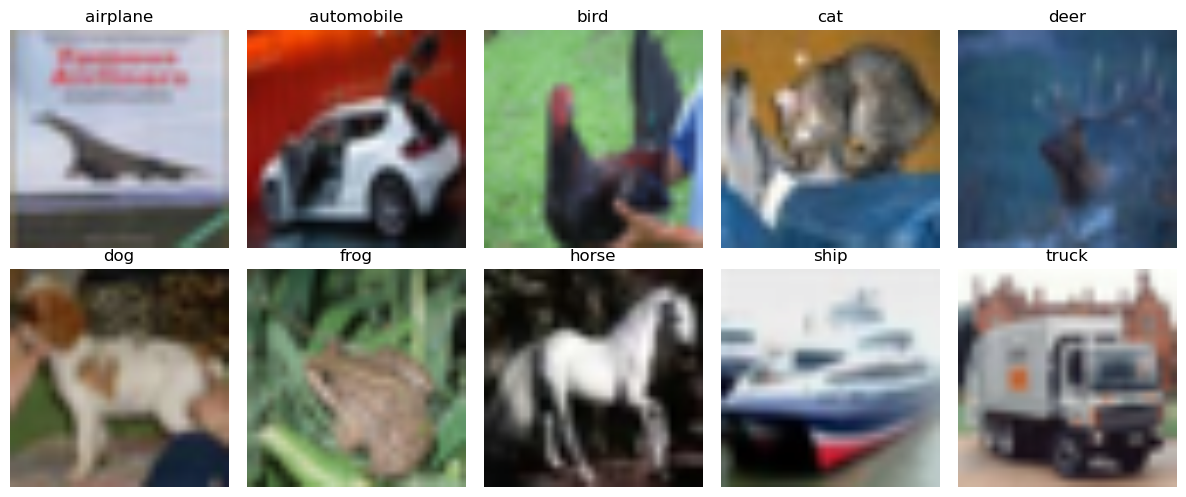


--- THÔNG SỐ KỸ THUẬT ---
Kích thước ảnh sau transform: torch.Size([3, 224, 224]) (C, H, W)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 1. Kiểm tra số lượng và danh sách lớp
classes = dataset.classes
total_samples = len(dataset)
print(f"--- THÔNG TIN BỘ DỮ LIỆU ---")
print(f"Tổng số lượng ảnh: {total_samples}")
print(f"Danh sách 10 lớp: {classes}")

# 2. Kiểm tra sự cân bằng giữa các lớp
# Lấy nhãn của toàn bộ dataset
all_labels = [dataset[i][1] for i in range(len(dataset))]
counts = Counter(all_labels)

print(f"\n--- THỐNG KÊ SỐ LƯỢNG MỖI LỚP ---")
for i, name in enumerate(classes):
    print(f"Lớp {i} ({name:<10}): {counts[i]} ảnh")

# 3. Hiển thị ảnh mẫu để kiểm tra trực quan
def imshow(img):
    # Đưa ảnh về dạng numpy và đảo ngược quá trình Normalize để nhìn rõ màu
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean # Denormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)

plt.figure(figsize=(12, 5))
print(f"\n--- HIỂN THỊ ẢNH MẪU ---")
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Lấy một ảnh bất kỳ từ mỗi lớp
    idx = all_labels.index(i)
    img, label = dataset[idx]
    imshow(img)
    plt.title(f"{classes[label]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 4. Kiểm tra chiều dữ liệu (Shape)
sample_img, _ = dataset[0]
print(f"\n--- THÔNG SỐ KỸ THUẬT ---")
print(f"Kích thước ảnh sau transform: {sample_img.shape} (C, H, W)")